In [1]:
# USE KAIJU/KAIPY KERNEL
import os
import h5py
import pandas as pd
import numpy as np
import scipy.stats as sps
import cdflib
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.time import Time #For converting MJD to datetime
plt.style.use('~/plots/paper.mplstyle')

import kaipy.kaiViz as kv
import kaipy.kaiH5 as kh5
import kaipy.gamera.magsphere as msph
import kaipy.kaiTools as ktools
import kaipy.supermage as smage

import ensemble_lib as el
import supermag_api as smapi #Acquired from https://supermag.jhuapl.edu/mag/lib/content/api/supermag-api.py

# Just trying out these colors, they ought to be changed in the future
r = '#BB3E03'
g = '#AE2012'
b = '#005F73'

/glade/work/cobrien/conda-envs/kaiju-3.12/lib/python3.12/site-packages/bezpy/mt/io.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
rundir_mean = "/glade/derecho/scratch/cobrien/doctor-patient-day-prime/"
runid_mean = "dptd-prime"
rundir_high = "/glade/derecho/scratch/cobrien/doctor-patient-day-prime-high/"
runid_high = "dptd-prime-high"
rundir_low = "/glade/derecho/scratch/cobrien/doctor-patient-day-prime-low/"
runid_low = "dptd-prime-low"
rundir_omni = "/glade/derecho/scratch/cobrien/doctor-patient-day-omni/"
runid_omni = "dptd-omni"
rundir_omniw = "/glade/derecho/scratch/cobrien/doctor-patient-day-omniw/"
runid_omniw = "dptd-omniw"

indices_mean = el.extract_indices(rundir_mean, runid_mean, deltab_extension=".deltab_lowres.h5")
indices_mean = indices_mean.loc[1:, :].reset_index(drop = True) #The first entry is funky, might be a bonus from spinup
indices_high = el.extract_indices(rundir_high, runid_high, deltab_extension=".deltab_lowres.h5")
indices_high = indices_high.loc[1:, :].reset_index(drop = True)
indices_low = el.extract_indices(rundir_low, runid_low, deltab_extension=".deltab_lowres.h5")
indices_low = indices_low.loc[1:, :].reset_index(drop = True)
indices_omni = el.extract_indices(rundir_omni, runid_omni)
indices_omni = indices_omni.loc[1:, :].reset_index(drop = True)
indices_omniw = el.extract_indices(rundir_omniw, runid_omniw)
indices_omniw = indices_omniw.loc[1:, :].reset_index(drop = True)

# Load the SuperMAG indices (combined over all stations)
status, indices_real = smapi.SuperMAGGetIndices('cobrien', '2013-03-17T0000', 86400, 'SMU, SML, SME, SMR')
indices_real['Epoch'] = pd.to_datetime(indices_real['tval'], origin = 'unix', unit = 's', utc = True)
indices_real = indices_real.rename(columns = {'smr' : 'SMR'}) # Why... is the SMR lowercase...

Initializing Earth magnetosphere
Opening pipe: /glade/derecho/scratch/cobrien/doctor-patient-day-prime/ : dptd-prime
/glade/derecho/scratch/cobrien/doctor-patient-day-prime//dptd-prime.h5 not found, looking for MPI database
	Found 16 = (4,4,1) ranks


Found 1442 timesteps
	Time = [-7200.000000,86400.003649]
	Steps = [0,1441]
Grid size = (96,96,128)
	Cells = 1.179648e+06
Variables (Root/Step) = (8,23)
	Root: ['Bx0', 'BxD', 'By0', 'ByD', 'Bz0', 'BzD', 'dV', 'timeAttributeCache']
	Step: ['Bx', 'By', 'Bz', 'Cs', 'D', 'Jx', 'Jy', 'Jz', 'P', 'Pb', 'SrcDT', 'SrcD_COLD', 'SrcD_RING', 'SrcIONEx', 'SrcIONEy', 'SrcIONEz', 'SrcP_COLD', 'SrcP_RING', 'SrcX1', 'SrcX2', 'Vx', 'Vy', 'Vz']
GameraPipe: b'EARTH'
setting UnitsID
Units Type = EARTH
dptd-prime/Grid |●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●| 16/16 [100%] in 1.5s (10.63/s) 
Found MJD data
	Time (Min/Max) = 56367.916667/56369.000000
Found ReMIX data, reading ...
GameraPipe: b'ReMIX'
setting UnitsID
|●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●| 1/1 [100%] in 0.0s (56.06/s) 
Initializing Earth magnetosphere
Opening pipe: /glade/derecho/scratch/cobrien/doctor-patient-day-prime/ : dptd-prime
/glade/derecho/scratch/cobrien/doctor-patient-day-prime//dptd-prime.h5 not found, looking for MPI database
	Found 16 = (4,4,1) r

In [3]:
# Load the perturbation maps from the simulation outputs

data_mean, info_mean = el.extract_perturbations(
    "/glade/derecho/scratch/cobrien/doctor-patient-day-prime/", # Run directory
    "dptd-prime", # Run ID
    deltab_extension=".deltab_lowres.h5",
)
im_arr_mean = el.bin_indices(data_mean) # Create binned SuperMAG indices and dB/dt

data_high, info_high = el.extract_perturbations(
    "/glade/derecho/scratch/cobrien/doctor-patient-day-prime-high/", # Run directory
    "dptd-prime-high", # Run ID
    deltab_extension=".deltab_lowres.h5",
)
im_arr_high = el.bin_indices(data_high) # Create binned SuperMAG indices and dB/dt

data_low, info_low = el.extract_perturbations(
    "/glade/derecho/scratch/cobrien/doctor-patient-day-prime-low/", # Run directory
    "dptd-prime-low", # Run ID
    deltab_extension=".deltab_lowres.h5",
)
im_arr_low = el.bin_indices(data_low) # Create binned SuperMAG indices and dB/dt

data_omni, info_omni = el.extract_perturbations(
    "/glade/derecho/scratch/cobrien/doctor-patient-day-omni/", # Run directory
    "dptd-omni", # Run ID
)
im_arr_omni = el.bin_indices(data_omni) # Create binned SuperMAG indices and dB/dt

data_omniw, info_omniw = el.extract_perturbations(
    "/glade/derecho/scratch/cobrien/doctor-patient-day-omniw/", # Run directory
    "dptd-omniw", # Run ID
)
im_arr_omniw = el.bin_indices(data_omniw) # Create binned SuperMAG indices and dB/dt

/glade/u/home/cobrien/mage-sensitivity-codes/ensemble_lib.py:215: RuntimeWarning: All-NaN slice encountered
  im_arr[:, i, 0] = np.nanmax(np.nanmax(dbn_ma, axis = 1), axis = 1) # Max dBn in the bin (SMU)
/glade/u/home/cobrien/mage-sensitivity-codes/ensemble_lib.py:216: RuntimeWarning: All-NaN slice encountered
  im_arr[:, i, 1] = np.nanmin(np.nanmin(dbn_ma, axis = 1), axis = 1) # Min dBn in the bin (SML)
/glade/u/home/cobrien/mage-sensitivity-codes/ensemble_lib.py:217: RuntimeWarning: All-NaN slice encountered
  im_arr[:, i, 3] = np.nanmax(np.nanmax(dbdt_ma, axis = 1), axis = 1) # Max dB/dt in the bin


In [4]:
# Load cached SuperMAG per-station data (load time 3 minutes with commented out code below)
status, inventory = smapi.SuperMAGGetInventory('cobrien', '2013-03-17T0000', 86400)
smag_combined = []
for idx, station in enumerate(inventory):
    print(f'Loading {station} ({idx} of {len(inventory)})', end = '\r')
    status, station_data = smapi.SuperMAGGetData('cobrien', '2013-03-17T0000', 86400, 'MLT', station)
    if len(station_data) == 1: #Empty stations sometimes end up in SuperMAGGetInventory, and they show up as single-entry dataframes when loaded by SuperMAGGetData
        continue
    smag_combined.append(station_data)
smag_df = pd.concat(smag_combined, ignore_index=True)

# The SuperMAG API returns dataframes of dictionaries for some reason. 
# This could work if they returned xarrays, but for dataframes it breaks any vectorized calculation.
# So we have to process each entry... and do some other things like reformat the time into datetime objects
new_components = ['N.nez', 'N.geo', 'E.nez', 'E.geo', 'Z.nez', 'Z.geo']
for component in new_components:
    smag_df[component] = np.nan

for i, idx in enumerate(smag_df.index):
    for component in new_components:
        smag_df.loc[idx, component] = smag_df.loc[idx, component.split(sep='.')[0]][component.split(sep='.')[1]]

# Then calculate dB/dt
smag_df['dBdt'] = np.nan # Add this seperately because it involves a computation later
for i, idx in enumerate(smag_df.index):
    if (i == 0) | (i == len(smag_df)-1): #Skip the first and last entries because we can't do their time derivative
            continue
    d1 = 0.5*(smag_df.iloc[i+1]['Z.nez'] - smag_df.iloc[i-1]['Z.nez']) # dBr/dt (radial GEO)
    d2 = 0.5*(smag_df.iloc[i+1]['E.nez'] - smag_df.iloc[i-1]['E.nez']) # dBt(heta)/dt (theta GEO)
    d3 = 0.5*(smag_df.iloc[i+1]['N.nez'] - smag_df.iloc[i-1]['N.nez']) # dBp/dt (phi GEO)
    smag_df.loc[idx, 'dBdt'] = np.sqrt(d1**2.0 + d2**2.0 + d3**2.0)

smag_df['tval'] = pd.to_datetime(smag_df['tval'], origin = 'unix', unit = 's', utc = True)

ValueError: invalid literal for int() with base 10: '<br />'

In [ ]:
fig, ax = plt.subplots(4, 1, sharex = True, figsize = (12,10))
plt.subplots_adjust(hspace = 0)

ax[0].plot(indices_mean['Epoch'], indices_mean['SMU'], label = 'Mean', color = g)
ax[0].fill_between(indices_high['Epoch'], indices_mean['SMU'], indices_high['SMU'], label = r"$1\sigma$ Envelope", color = r, alpha = 0.5, edgecolor = None)
ax[0].fill_between(indices_high['Epoch'], indices_mean['SMU'], indices_low['SMU'], color = r, alpha = 0.5, edgecolor = None)
ax[0].plot(indices_omniw['Epoch'], indices_omniw['SMU'], label = 'Wind', color = b, alpha = 1)
ax[0].plot(indices_omni['Epoch'], indices_omni['SMU'], label = 'OMNI', color = 'k', alpha = 0.5)
ax[0].plot(indices_real['Epoch'], indices_real['SMU'], label = 'SuperMAG', color = 'k', ls = '--')
ax[0].set_ylabel("SMU (nT)")

ax[1].plot(indices_mean['Epoch'], indices_mean['SML'], label = 'Mean', color = g)
ax[1].fill_between(indices_high['Epoch'], indices_mean['SML'], indices_high['SML'], label = r"$1\sigma$ Envelope", color = r, alpha = 0.5, edgecolor = None)
ax[1].fill_between(indices_high['Epoch'], indices_mean['SML'], indices_low['SML'], color = r, alpha = 0.5, edgecolor = None)
ax[1].plot(indices_omniw['Epoch'], indices_omniw['SML'], label = 'Wind', color = b, alpha = 1)
ax[1].plot(indices_omni['Epoch'], indices_omni['SML'], label = 'OMNI', color = 'k', alpha = 0.5)
ax[1].plot(indices_real['Epoch'], indices_real['SML'], label = 'SuperMAG', color = 'k', ls = '--')
ax[1].set_ylabel("SML (nT)")

ax[2].plot(indices_mean['Epoch'], indices_mean['SME'], label = 'Mean', color = g)
ax[2].fill_between(indices_high['Epoch'], indices_mean['SME'], indices_high['SME'], label = r"$1\sigma$ Envelope", color = r, alpha = 0.5, edgecolor = None)
ax[2].fill_between(indices_high['Epoch'], indices_mean['SME'], indices_low['SME'], color = r, alpha = 0.5, edgecolor = None)
ax[2].plot(indices_omniw['Epoch'], indices_omniw['SME'], label = 'Wind', color = b, alpha = 1)
ax[2].plot(indices_omni['Epoch'], indices_omni['SME'], label = 'OMNI', color = 'k', alpha = 0.5)
ax[2].plot(indices_real['Epoch'], indices_real['SME'], label = 'SuperMAG', color = 'k', ls = '--')
ax[2].set_ylabel("SME (nT)")
ax[2].legend(frameon = False)

ax[3].plot(indices_mean['Epoch'], indices_mean['SMR'], label = 'Mean', color = g)
ax[3].fill_between(indices_high['Epoch'], indices_mean['SMR'], indices_high['SMR'], label = r"$1\sigma$ Envelope", color = r, alpha = 0.5, edgecolor = None)
ax[3].fill_between(indices_high['Epoch'], indices_mean['SMR'], indices_low['SMR'], color = r, alpha = 0.5, edgecolor = None)
ax[3].plot(indices_omniw['Epoch'], indices_omniw['SMR'], label = 'Wind', color = b, alpha = 1)
ax[3].plot(indices_omni['Epoch'], indices_omni['SMR'], label = 'OMNI', color = 'k', alpha = 0.5)
ax[3].plot(indices_real['Epoch'], indices_real['SMR'], label = 'SuperMAG', color = 'k', ls = '--')
ax[3].set_ylabel("SMR (nT)")

ax[3].set_xticklabels(ax[3].get_xticklabels(), rotation=45, ha = "right", rotation_mode='anchor')
bounds = [pd.to_datetime('2013-03-17 00:00:00+0000'), pd.to_datetime('2013-03-18 00:00:00+0000')]
ax[3].set_xlim(bounds[0], bounds[1])
n_ticks = 7
ax[3].set_xticks(pd.date_range(start = bounds[0], end = bounds[1], periods = n_ticks))
_ = ax[3].set_xticklabels(pd.date_range(start = bounds[0], end = bounds[1], periods = n_ticks).strftime('%H:%M'),
                      rotation=45, ha = "right", rotation_mode='anchor')
# plt.savefig('plots/supermag_gemmdt.pdf', bbox_inches = 'tight')

In [ ]:
print(f"PRIME Mean run minimum SMR: {indices_mean['SMR'].min()}")
print(f"PRIME High run minimum SMR: {indices_high['SMR'].min()}")
print(f"PRIME Low run minimum SMR: {indices_low['SMR'].min()}")
print(f"OMNI run minimum SMR: {indices_omni['SMR'].min()}")
print(f"OMNIW run minimum SMR: {indices_omniw['SMR'].min()}")
print(f"SuperMAG minimum SMR: {indices_real['SMR'].min()}")

PRIME Mean run minimum SMR: -100.05099646526219
PRIME High run minimum SMR: -144.50078986827268
PRIME Low run minimum SMR: -63.49981355089206
OMNI run minimum SMR: -93.64522719683524
OMNIW run minimum SMR: -93.59853260929262
SuperMAG minimum SMR: -140.421661


In [ ]:
# Metrics Zone
threshold = None # Standard deviations above mean we calculate metric on
print(f"Threshold >{threshold} stdev above mean.\n")
for index in ['SMU', 'SML', 'SME', 'SMR']:
    if threshold != None:
        cut = np.abs(indices_real[index]) > (threshold * np.std(indices_real[index]) + np.mean(np.abs(indices_real[index])))
    else:
        cut = np.ones(len(indices_real), dtype = bool)
    # Mean Error
    mean_me = np.mean((indices_mean[index][cut] - indices_real[index][cut]))
    high_me = np.mean((indices_high[index][cut] - indices_real[index][cut]))
    low_me = np.mean((indices_low[index][cut] - indices_real[index][cut]))
    omni_me = np.mean((indices_omni[index][cut] - indices_real[index][cut]))
    omniw_me = np.mean((indices_omniw[index][cut] - indices_real[index][cut]))
    print(
        f"{index} ME:\nMean Driving, {mean_me:.2f}nT\nHigh Driving, {high_me:.2f}nT\nLow Driving, {low_me:.2f}nT\nOMNI Driving, {omni_me:.2f}nT\nOMNIW Driving, {omniw_me:.2f}nT\n"
    )
    # Mean Absolute Error
    mean_mae = np.mean(np.abs(indices_mean[index][cut] - indices_real[index][cut]))
    high_mae =np.mean(np.abs(indices_high[index][cut] - indices_real[index][cut]))
    low_mae = np.mean(np.abs(indices_low[index][cut] - indices_real[index][cut]))
    omni_mae = np.mean(np.abs(indices_omni[index][cut] - indices_real[index][cut]))
    omniw_mae = np.mean(np.abs(indices_omniw[index][cut] - indices_real[index][cut]))
    print(
        f"{index} MAE:\nMean Driving, {mean_mae:.2f}\nHigh Driving, {high_mae:.2f}\nLow Driving, {low_mae:.2f}\nOMNI Driving, {omni_mae:.2f}\nOMNIW Driving, {omniw_mae:.2f}\n"
    )
    # SE (Skew Error), measure of whether the skew of the model and data match. SE > 0 is overpredicted skew, SE < 0 is underpredicted skew
    mean_se = np.mean((indices_mean[index][cut] - indices_real[index][cut])**3) / np.std(indices_mean[index][cut])**3
    high_se = np.mean((indices_high[index][cut] - indices_real[index][cut])**3) / np.std(indices_high[index][cut])**3
    low_se = np.mean((indices_low[index][cut] - indices_real[index][cut])**3) / np.std(indices_low[index][cut])**3
    omni_se = np.mean((indices_omni[index][cut] - indices_real[index][cut])**3) / np.std(indices_omni[index][cut])**3
    omniw_se = np.mean((indices_omniw[index][cut] - indices_real[index][cut])**3) / np.std(indices_omniw[index][cut])**3
    print(
        f"{index} SE:\nMean Driving, {mean_se:.2f}\nHigh Driving, {high_se:.2f}\nLow Driving, {low_se:.2f}\nOMNI Driving, {omni_se:.2f}\nOMNIW Driving, {omniw_se:.2f}\n"
    )
    # KE (Kurtosis Error), measure of whether the kurtosis of the model and data match. KE > 0 is overpredicted kurtosis, KE < 0 is underpredicted kurtosis
    mean_ke = np.mean((indices_mean[index][cut] - indices_real[index][cut])**4) / np.std(indices_mean[index][cut])**4
    high_ke = np.mean((indices_high[index][cut] - indices_real[index][cut])**4) / np.std(indices_high[index][cut])**4
    low_ke = np.mean((indices_low[index][cut] - indices_real[index][cut])**4) / np.std(indices_low[index][cut])**4
    omni_ke = np.mean((indices_omni[index][cut] - indices_real[index][cut])**4) / np.std(indices_omni[index][cut])**4
    omniw_ke = np.mean((indices_omniw[index][cut] - indices_real[index][cut])**4) / np.std(indices_omniw[index][cut])**4
    print(
        f"{index} KE:\nMean Driving, {mean_ke:.2f}\nHigh Driving, {high_ke:.2f}\nLow Driving, {low_ke:.2f}\nOMNI Driving, {omni_ke:.2f}\nOMNIW Driving, {omniw_ke:.2f}\n"
    )

Threshold >None stdev above mean.

SMU SE:
Mean Driving, -0.30
High Driving, 0.78
Low Driving, -5.36
OMNI Driving, -1.18
OMNIW Driving, -1.28

SMU KE:
Mean Driving, 1.92
High Driving, 1.80
Low Driving, 16.60
OMNI Driving, 4.69
OMNIW Driving, 5.81

SML SE:
Mean Driving, 0.10
High Driving, -1.23
Low Driving, 4.78
OMNI Driving, 0.12
OMNIW Driving, 0.21

SML KE:
Mean Driving, 1.31
High Driving, 2.00
Low Driving, 15.67
OMNI Driving, 1.15
OMNIW Driving, 1.32

SME SE:
Mean Driving, -0.14
High Driving, 1.00
Low Driving, -4.43
OMNI Driving, -0.15
OMNIW Driving, -0.23

SME KE:
Mean Driving, 1.07
High Driving, 1.62
Low Driving, 13.04
OMNI Driving, 0.85
OMNIW Driving, 1.05

SMR SE:
Mean Driving, 0.28
High Driving, -0.17
Low Driving, 18.70
OMNI Driving, 1.28
OMNIW Driving, 1.49

SMR KE:
Mean Driving, 0.36
High Driving, 0.13
Low Driving, 66.14
OMNI Driving, 2.09
OMNIW Driving, 2.46



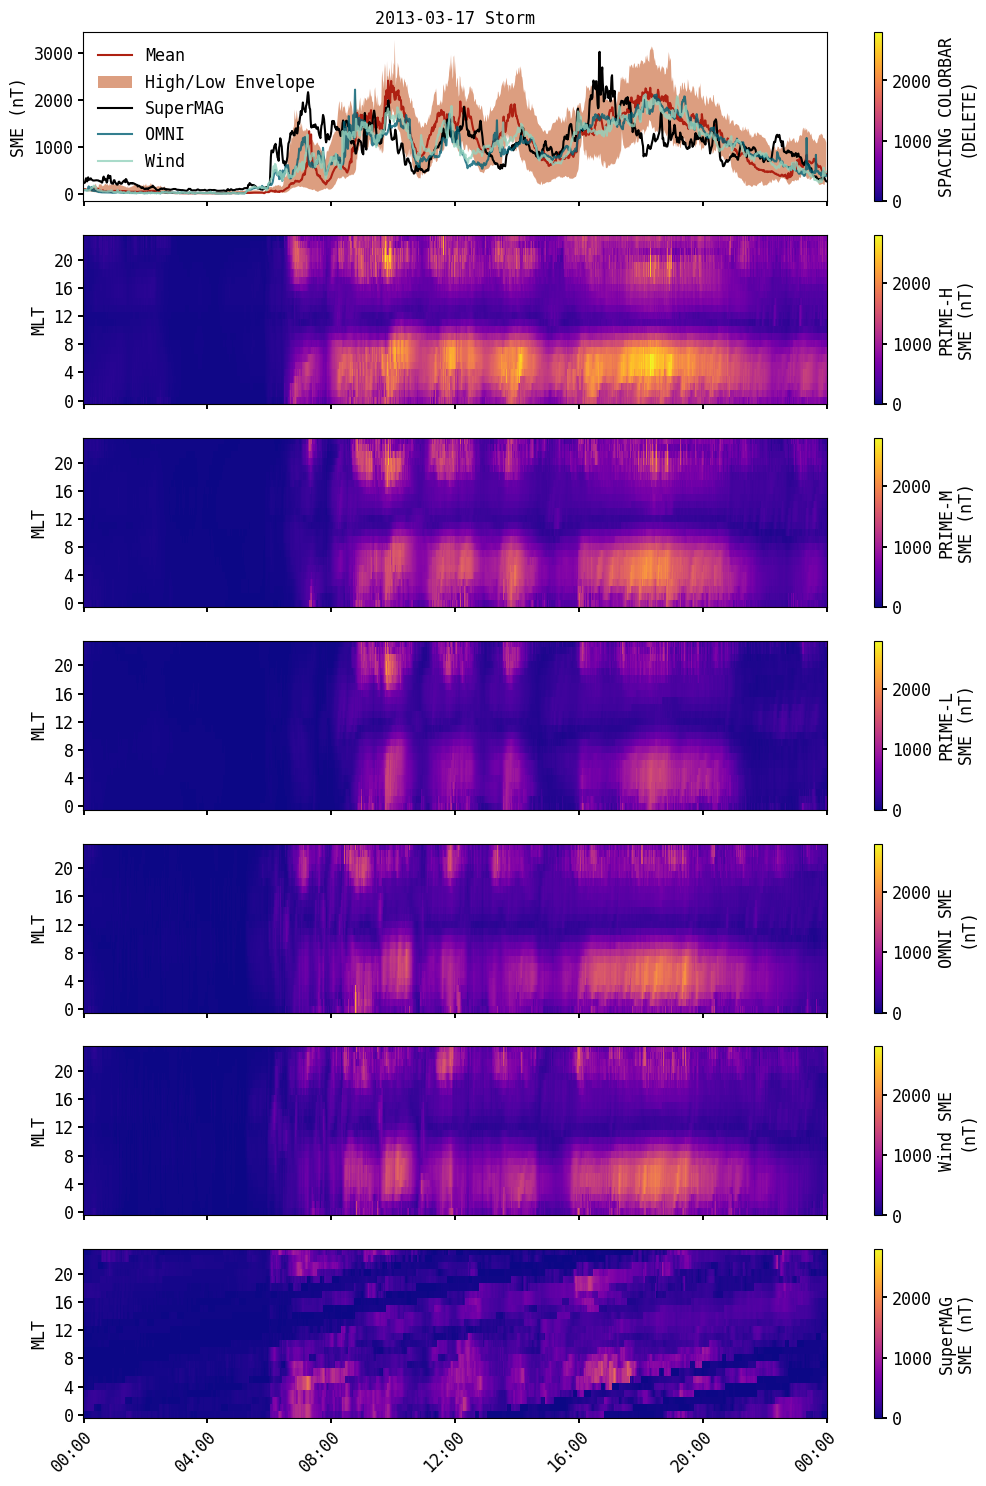

In [ ]:
fig, ax = plt.subplots(7,1,figsize = (12, 18), sharex=True)

ax[0].plot(np.arange(len(indices_mean)), indices_mean['SME'], label = 'Mean', color = g)
ax[0].fill_between(np.arange(len(indices_mean)), indices_mean['SME'], indices_high['SME'], label = "High/Low Envelope", color = r, alpha = 0.5, edgecolor = None)
ax[0].fill_between(np.arange(len(indices_mean)), indices_mean['SME'], indices_low['SME'], color = r, alpha = 0.5, edgecolor = None)
ax[0].plot(np.arange(len(indices_real)), indices_real['SME'], label = 'SuperMAG', color = 'k')
ax[0].plot(np.arange(len(indices_omni)), indices_omni['SME'], label = 'OMNI', color = b, alpha = 0.8)
ax[0].plot(np.arange(len(indices_omniw)), indices_omniw['SME'], label = 'Wind', color = '#94d2bdff', alpha = 0.8)
ax[0].set_ylabel("SME (nT)")
ax[0].legend(frameon = False)
ax[0].set_title("2013-03-17 Storm")

im0 = ax[1].imshow(im_arr_high[:,:,2].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 2800)
plt.colorbar(im0, ax=ax[1], label = f"PRIME-H\nSME (nT)")
plt.colorbar(im0, ax=ax[0], label = f"SPACING COLORBAR\n(DELETE)")
ax[1].set_yticks([0,4,8,12,16,20])
ax[1].set_ylabel("MLT")

im1 = ax[2].imshow(im_arr_mean[:,:,2].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 2800)
plt.colorbar(im1, ax=ax[2], label = f"PRIME-M\nSME (nT)")
ax[2].set_yticks([0,4,8,12,16,20,])
ax[2].set_ylabel("MLT")

im2 = ax[3].imshow(im_arr_low[:,:,2].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 2800)
plt.colorbar(im2, ax=ax[3], label = f"PRIME-L\nSME (nT)")
ax[3].set_yticks([0,4,8,12,16,20,])
ax[3].set_ylabel("MLT")

im3 = ax[4].imshow(im_arr_omni[:,:,2].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 2800)
plt.colorbar(im3, ax=ax[4], label = f"OMNI SME\n(nT)")
ax[4].set_yticks([0,4,8,12,16,20,])
ax[4].set_ylabel("MLT")

im4 = ax[5].imshow(im_arr_omniw[:,:,2].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 2800)
plt.colorbar(im4, ax=ax[5], label = f"Wind SME\n(nT)")
ax[5].set_yticks([0,4,8,12,16,20,])
ax[5].set_ylabel("MLT")

im5 = ax[6].imshow(im_arr_real[:,:,2].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 2800)
plt.colorbar(im5, ax=ax[6], label = f"SuperMAG\nSME (nT)")
ax[6].set_yticks([0,4,8,12,16,20,])
ax[6].set_ylabel("MLT")

n_ticks = 7
ax[-1].set_xticks(np.linspace(0,len(im_arr_mean[:,:,2]), n_ticks))
_ = ax[-1].set_xticklabels(pd.date_range(start = '2013-03-17 00:00:00+0000', end = '2013-03-18 00:00:00+0000', periods = n_ticks).strftime('%H:%M'),
                      rotation=45, ha = "right", rotation_mode='anchor')
# plt.savefig('plots/sme_comparison.pdf', bbox_inches = 'tight', dpi = 300)

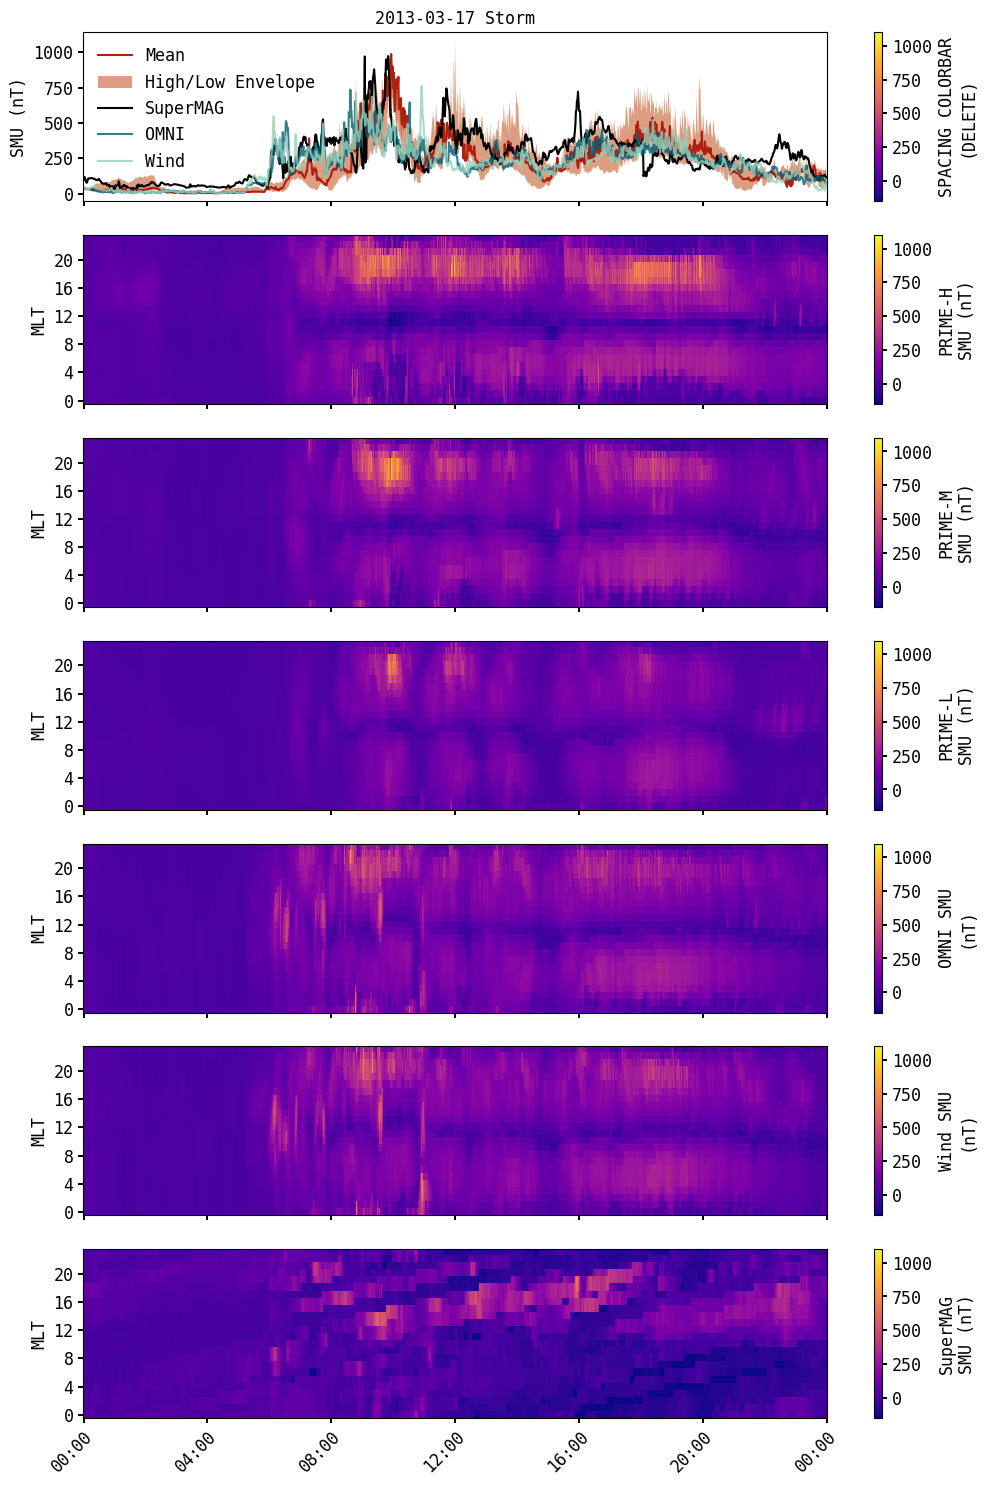

In [ ]:
fig, ax = plt.subplots(7,1,figsize = (12, 18), sharex=True)

ax[0].plot(np.arange(len(indices_mean)), indices_mean['SMU'], label = 'Mean', color = g)
ax[0].fill_between(np.arange(len(indices_mean)), indices_mean['SMU'], indices_high['SMU'], label = "High/Low Envelope", color = r, alpha = 0.5, edgecolor = None)
ax[0].fill_between(np.arange(len(indices_mean)), indices_mean['SMU'], indices_low['SMU'], color = r, alpha = 0.5, edgecolor = None)
ax[0].plot(np.arange(len(indices_real)), indices_real['SMU'], label = 'SuperMAG', color = 'k')
ax[0].plot(np.arange(len(indices_omni)), indices_omni['SMU'], label = 'OMNI', color = b, alpha = 0.8)
ax[0].plot(np.arange(len(indices_omniw)), indices_omniw['SMU'], label = 'Wind', color = '#94d2bdff', alpha = 0.8)
ax[0].set_ylabel("SMU (nT)")
ax[0].legend(frameon = False)
ax[0].set_title("2013-03-17 Storm")

im0 = ax[1].imshow(im_arr_high[:,:,0].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = -150, vmax = 1100)
plt.colorbar(im0, ax=ax[1], label = f"PRIME-H\nSMU (nT)")
plt.colorbar(im0, ax=ax[0], label = f"SPACING COLORBAR\n(DELETE)")
ax[1].set_yticks([0,4,8,12,16,20,])
ax[1].set_ylabel("MLT")

im1 = ax[2].imshow(im_arr_mean[:,:,0].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = -150, vmax = 1100)
plt.colorbar(im1, ax=ax[2], label = f"PRIME-M\nSMU (nT)")
ax[2].set_yticks([0,4,8,12,16,20,])
ax[2].set_ylabel("MLT")

im2 = ax[3].imshow(im_arr_low[:,:,0].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = -150, vmax = 1100)
plt.colorbar(im2, ax=ax[3], label = f"PRIME-L\nSMU (nT)")
ax[3].set_yticks([0,4,8,12,16,20,])
ax[3].set_ylabel("MLT")

im3 = ax[4].imshow(im_arr_omni[:,:,0].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = -150, vmax = 1100)
plt.colorbar(im3, ax=ax[4], label = f"OMNI SMU\n(nT)")
ax[4].set_yticks([0,4,8,12,16,20,])
ax[4].set_ylabel("MLT")

im4 = ax[5].imshow(im_arr_omniw[:,:,0].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = -150, vmax = 1100)
plt.colorbar(im4, ax=ax[5], label = f"Wind SMU\n(nT)")
ax[5].set_yticks([0,4,8,12,16,20,])
ax[5].set_ylabel("MLT")

im5 = ax[6].imshow(im_arr_real[:,:,0].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = -150, vmax = 1100)
plt.colorbar(im5, ax=ax[6], label = f"SuperMAG\nSMU (nT)")
ax[6].set_yticks([0,4,8,12,16,20,])
ax[6].set_ylabel("MLT")

n_ticks = 7
ax[-1].set_xticks(np.linspace(0,len(im_arr_omni[:,:,0]), n_ticks))
_ = ax[-1].set_xticklabels(pd.date_range(start = '2013-03-17 00:00:00+0000', end = '2013-03-18 00:00:00+0000', periods = n_ticks).strftime('%H:%M'),
                      rotation=45, ha = "right", rotation_mode='anchor')
# plt.savefig('plots/smu_comparison.pdf', bbox_inches = 'tight', dpi = 300)

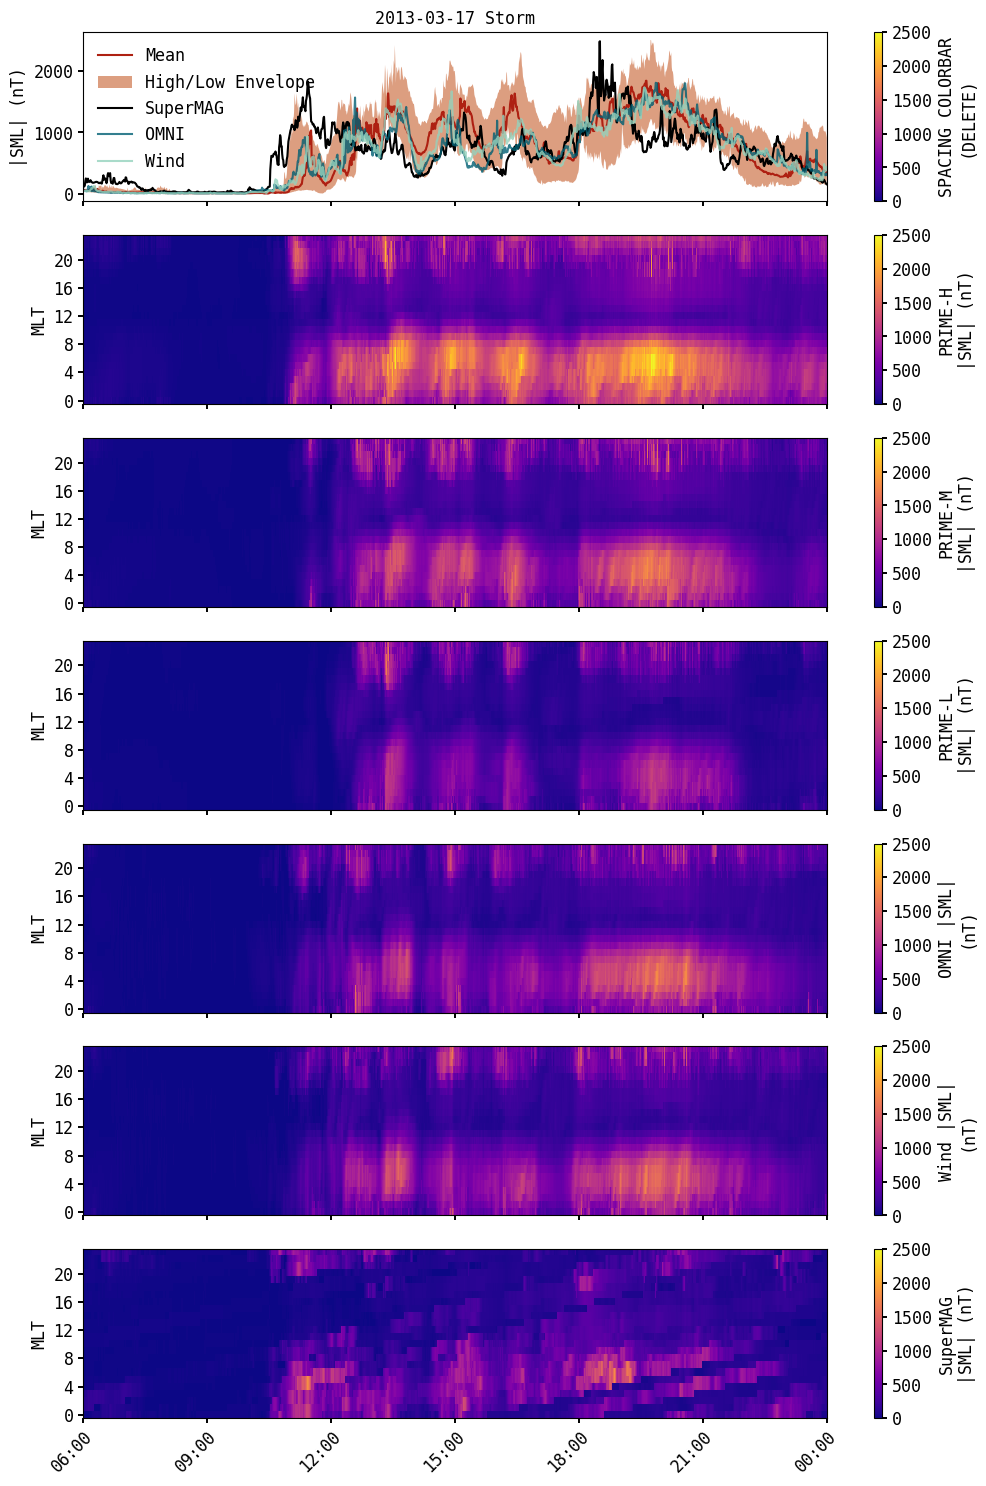

: 

In [ ]:
fig, ax = plt.subplots(7,1,figsize = (12, 18), sharex=True)

im0 = ax[1].imshow(-im_arr_high[:,:,1].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 2500)
plt.colorbar(im0, ax=ax[1], label = f"PRIME-H\n|SML| (nT)")
ax[1].set_yticks([0,4,8,12,16,20,])
ax[1].set_ylabel("MLT")
# ax[1].set_title("2013-03-17 Storm")

ax[0].plot(np.arange(len(indices_mean)), -1*indices_mean['SML'], label = 'Mean', color = g)
plt.colorbar(im0, ax=ax[0], label = f"SPACING COLORBAR\n(DELETE)")
ax[0].fill_between(np.arange(len(indices_mean)), -1*indices_mean['SML'], -1*indices_high['SML'], label = "High/Low Envelope", color = r, alpha = 0.5, edgecolor = None)
ax[0].fill_between(np.arange(len(indices_mean)), -1*indices_mean['SML'], -1*indices_low['SML'], color = r, alpha = 0.5, edgecolor = None)
ax[0].plot(np.arange(len(indices_real)), -1*indices_real['SML'], label = 'SuperMAG', color = 'k')
ax[0].plot(np.arange(len(indices_omni)), -1*indices_omni['SML'], label = 'OMNI', color = b, alpha = 0.8)
ax[0].plot(np.arange(len(indices_omniw)), -1*indices_omniw['SML'], label = 'Wind', color = '#94d2bdff', alpha = 0.8)
ax[0].set_ylabel("|SML| (nT)")
ax[0].legend(frameon = False)

im1 = ax[2].imshow(-1 * im_arr_mean[:,:,1].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 2500)
plt.colorbar(im1, ax=ax[2], label = f"PRIME-M\n|SML| (nT)")
ax[2].set_yticks([0,4,8,12,16,20,])
ax[2].set_ylabel("MLT")

im2 = ax[3].imshow(-1 * im_arr_low[:,:,1].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 2500)
plt.colorbar(im2, ax=ax[3], label = f"PRIME-L\n|SML| (nT)")
ax[3].set_yticks([0,4,8,12,16,20,])
ax[3].set_ylabel("MLT")

im3 = ax[4].imshow(-1 * im_arr_omni[:,:,1].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 2500)
plt.colorbar(im3, ax=ax[4], label = f"OMNI |SML|\n(nT)")
ax[4].set_yticks([0,4,8,12,16,20,])
ax[4].set_ylabel("MLT")

im4 = ax[5].imshow(-1 * im_arr_omniw[:,:,1].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 2500)
plt.colorbar(im4, ax=ax[5], label = f"Wind |SML|\n(nT)")
ax[5].set_yticks([0,4,8,12,16,20,])
ax[5].set_ylabel("MLT")

im5 = ax[6].imshow(-1 * im_arr_real[:,:,1].T, cmap = 'plasma', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 2500)
plt.colorbar(im5, ax=ax[6], label = f"SuperMAG\n|SML| (nT)")
ax[6].set_yticks([0,4,8,12,16,20,])
ax[6].set_ylabel("MLT")

n_ticks = 7
h = 0
m = 0
ax[-1].set_xlim(int(h*60.0), len(im_arr_real[:,:,1]))
ax[-1].set_xticks(np.linspace(int(h*60.0),len(im_arr_real[:,:,1]), n_ticks))
_ = ax[-1].set_xticklabels(pd.date_range(start = '2013-03-17 06:00:00+0000', end = '2013-03-18 00:00:00+0000', periods = n_ticks).strftime('%H:%M'),
                      rotation=45, ha = "right", rotation_mode='anchor')
# plt.savefig('plots/sml_comparison.pdf', bbox_inches = 'tight', dpi = 300)

In [ ]:
fig, ax = plt.subplots(5,1,figsize = (11, 8.5), sharex=True)

# Peak powerline Lon / Lat identified in GIC.ipynb
peak_pos = [-94.5594228377125, 48.6499948788717]
lon_idx, lat_idx = el.lonlat_tf(peak_pos[0], peak_pos[1]) # Get indices in h5 file corresponding to this lon/lat
# Make a timeseries of MLT at that peak position to overlay on dB/dt maps
f_high = h5py.File("/glade/derecho/scratch/cobrien/doctor-patient-day-prime-high/dptd-prime-high.deltab.h5", "r")
f_mean = h5py.File("/glade/derecho/scratch/cobrien/doctor-patient-day-prime-mean/dptd-prime-mean.deltab.h5", "r")
f_low = h5py.File("/glade/derecho/scratch/cobrien/doctor-patient-day-prime-low/dptd-prime-low.deltab.h5", "r")

peak_mlt = np.empty(len(im_arr_high), 3) # Array to hold peak positions in
for t_idx in range(len(im_arr_high)):
    peak_mlt[t_idx, 0] = 24 * (f_high[f'Step#{t_idx}']['smlon'][0, lon_idx, lat_idx] / 360)
    peak_mlt[t_idx, 1] = 24 * (f_mean[f'Step#{t_idx}']['smlon'][0, lon_idx, lat_idx] / 360)
    peak_mlt[t_idx, 2] = 24 * (f_low[f'Step#{t_idx}']['smlon'][0, lon_idx, lat_idx] / 360)

bounds = [int(9*60+10), int(10*60+10)]
t_bounds = ['2013-03-17 09:10:00+0000', '2013-03-17 10:10:00+0000']

im0 = ax[0].imshow(im_arr_high[bounds[0]:bounds[1],:,3].T, cmap = 'inferno', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 1700)
plt.colorbar(im0, ax=ax[0], label = f"PRIME-H $|dB/dt|$\n(nT/min)")
plt.plot(peak_mlt[:, 0], color = 'r')
ax[0].set_yticks([0,4,8,12,16,20,])
ax[0].set_ylabel("MLT")
ax[0].set_title("2013-03-17 Storm")

im1 = ax[1].imshow(im_arr_mean[bounds[0]:bounds[1],:,3].T, cmap = 'inferno', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 1700)
plt.colorbar(im1, ax=ax[1], label = f"PRIME-M $|dB/dt|$\n(nT/min)")
plt.plot(peak_mlt[:, 1], color = 'r')
ax[1].set_yticks([0,4,8,12,16,20,])
ax[1].set_ylabel("MLT")

im2 = ax[2].imshow(im_arr_low[bounds[0]:bounds[1],:,3].T, cmap = 'inferno', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 1700)
plt.colorbar(im2, ax=ax[2], label = f"PRIME-L $|dB/dt|$\n(nT/min)")
plt.plot(peak_mlt[:, 2], color = 'r')
ax[2].set_yticks([0,4,8,12,16,20,])
ax[2].set_ylabel("MLT")

im3 = ax[3].imshow(im_arr_omni[bounds[0]:bounds[1],:,3].T, cmap = 'inferno', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 1700)
plt.colorbar(im3, ax=ax[3], label = f"OMNI $|dB/dt|$\n(nT/min)")
ax[3].set_yticks([0,4,8,12,16,20,])
ax[3].set_ylabel("MLT")

im3 = ax[4].imshow(im_arr_real[bounds[0]:bounds[1],:,3].T, cmap = 'inferno', aspect = 'auto', interpolation = 'none', origin = 'lower', vmin = 0, vmax = 1700)
plt.colorbar(im3, ax=ax[4], label = f"OMNI $|dB/dt|$\n(nT/min)")
ax[4].set_yticks([0,4,8,12,16,20,])
ax[4].set_ylabel("MLT")

ax[0].axvline(9*60+48 - bounds[0], color = r, linestyle = '--')
ax[1].axvline(9*60+18 - bounds[0], color = r, linestyle = '--')
ax[2].axvline(9*60+45 - bounds[0], color = r, linestyle = '--')

n_ticks = 7
ax[4].set_xticks(np.linspace(0, bounds[1] - bounds[0], n_ticks))
_ = ax[4].set_xticklabels(pd.date_range(start = t_bounds[0], end = t_bounds[1], periods = n_ticks).strftime('%H:%M:%S'),
                      rotation=45, ha = "right", rotation_mode='anchor')
# plt.savefig('plots/dbdt_sectorial_small.pdf', bbox_inches = 'tight')

NameError: name 'plt' is not defined

<>:120: SyntaxWarning: invalid escape sequence '\s'
<>:130: SyntaxWarning: invalid escape sequence '\s'
<>:140: SyntaxWarning: invalid escape sequence '\s'
<>:120: SyntaxWarning: invalid escape sequence '\s'
<>:130: SyntaxWarning: invalid escape sequence '\s'
<>:140: SyntaxWarning: invalid escape sequence '\s'
/glade/derecho/scratch/cobrien/tmp/ipykernel_5723/3693636738.py:120: SyntaxWarning: invalid escape sequence '\s'
  ax[0].fill_between(sw_high['Epoch'], sw_mean['Vx']/1000, sw_high['Vx']/1000, label = f"$1\sigma$ Envelope", color = r, alpha = 0.5, edgecolor = None)
/glade/derecho/scratch/cobrien/tmp/ipykernel_5723/3693636738.py:130: SyntaxWarning: invalid escape sequence '\s'
  ax[1].fill_between(sw_high['Epoch'], sw_mean['D'], sw_high['D'], label = f"$1\sigma$ Envelope", color = r, alpha = 0.5, edgecolor = None)
/glade/derecho/scratch/cobrien/tmp/ipykernel_5723/3693636738.py:140: SyntaxWarning: invalid escape sequence '\s'
  ax[2].fill_between(sw_high['Epoch'], sw_mean['Pdyn'], s

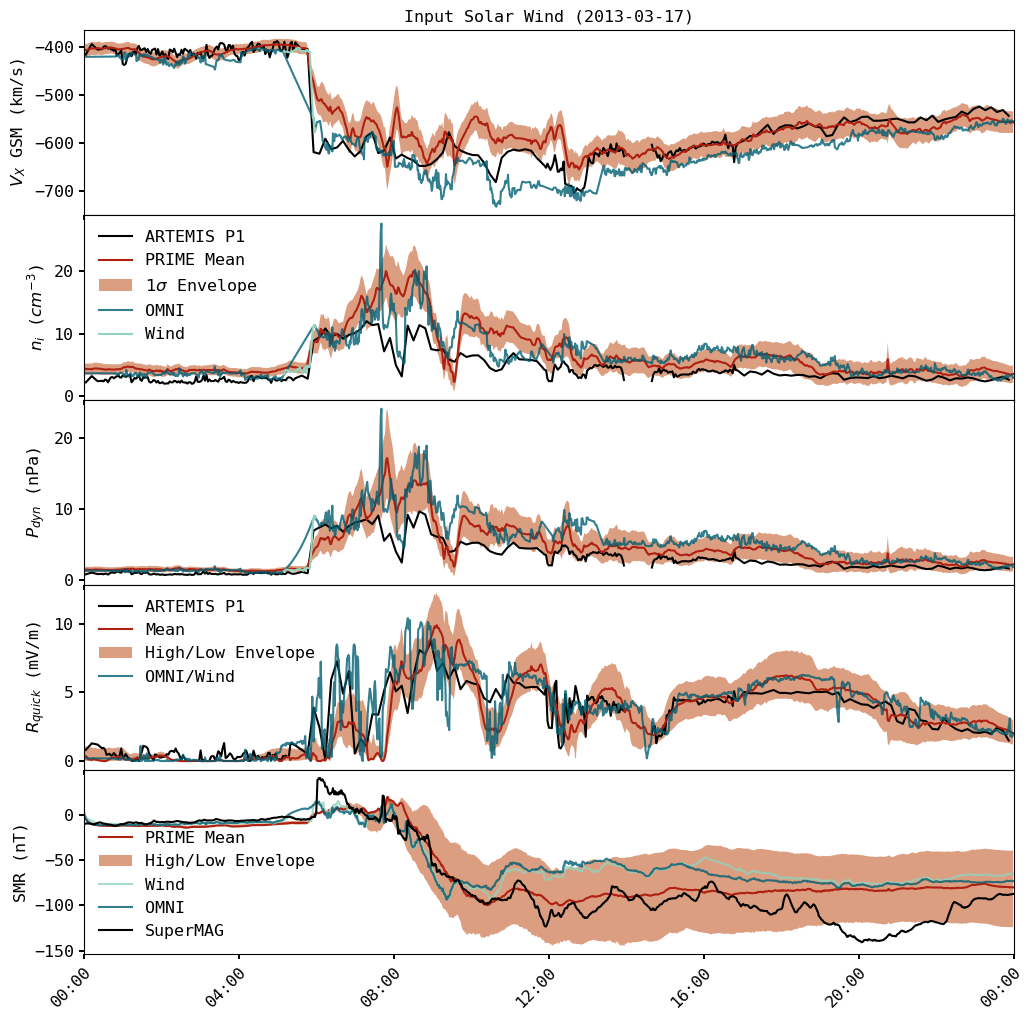

In [ ]:
sw_mean = el.extract_solarwind(rundir_mean)
sw_high = el.extract_solarwind(rundir_high)
sw_low = el.extract_solarwind(rundir_low)
sw_omni = el.extract_solarwind(rundir_omni)
sw_omniw = el.extract_solarwind(rundir_omniw)

themisb_ion = cdflib.CDF('/glade/u/home/cobrien/data/artemis/thb_l2_esa_20130317_v01.cdf')
themisb_mag = cdflib.CDF('/glade/u/home/cobrien/data/artemis/thb_l2_fgm_20130317_v01.cdf')
themisb_ion_df = pd.DataFrame(columns=['Epoch', 'D', 'Vx', 'Vy', 'Vz', 'T'])
themisb_mag_df = pd.DataFrame(columns=['Epoch', 'Bx', 'By', 'Bz'])
themisb_ion_df['Epoch'] = pd.to_datetime(themisb_ion['thb_peif_time']*(10**9), utc=True)
themisb_ion_df['D'] = themisb_ion['thb_peif_density']
themisb_ion_df['Vx'] = themisb_ion['thb_peif_velocity_gse'][:,0]
themisb_ion_df['Vy'] = themisb_ion['thb_peif_velocity_gse'][:,1]
themisb_ion_df['Vz'] = themisb_ion['thb_peif_velocity_gse'][:,2]
themisb_ion_df['T'] = themisb_ion['thb_peif_avgtemp']
themisb_ion_df = themisb_ion_df.loc[(themisb_ion_df['Epoch'] >= sw_mean['Epoch'].iloc[0])&(themisb_ion_df['Epoch'] <= sw_mean['Epoch'].iloc[-1])]

themisb_mag_df['Epoch'] = pd.to_datetime(themisb_mag['thb_fgs_time'][::10]*(10**9), utc=True)
themisb_mag_df['Bx'] = themisb_mag['thb_fgs_gsm'][::10,0]
themisb_mag_df['By'] = themisb_mag['thb_fgs_gsm'][::10,1]
themisb_mag_df['Bz'] = themisb_mag['thb_fgs_gsm'][::10,2]
themisb_mag_df = themisb_mag_df.loc[(themisb_mag_df['Epoch'] >= sw_mean['Epoch'].iloc[0])&(themisb_mag_df['Epoch'] <= sw_mean['Epoch'].iloc[-1])]

themisb_ion_df.loc[
    (themisb_ion_df['Epoch'] >= pd.to_datetime('2013-03-17 13:58:47.973881344+00:00'))&
    (themisb_ion_df['Epoch'] <= pd.to_datetime('2013-03-17 14:37:30.234348800+00:00')),
    ['D', 'Vx', 'Vy', 'Vz', 'T']
    ] = np.nan

sw_mean['Pdyn'] = 2e-6 * sw_mean['D'] * ((sw_mean['Vx']/1000)**2 + (sw_mean['Vy']/1000)**2 + (sw_mean['Vz']/1000)**2)
sw_high['Pdyn'] = 2e-6 * sw_high['D'] * ((sw_high['Vx']/1000)**2 + (sw_high['Vy']/1000)**2 + (sw_high['Vz']/1000)**2)
sw_low['Pdyn'] = 2e-6 * sw_low['D'] * ((sw_low['Vx']/1000)**2 + (sw_low['Vy']/1000)**2 + (sw_low['Vz']/1000)**2)
sw_omni['Pdyn'] = 2e-6 * sw_omni['D'] * ((sw_omni['Vx']/1000)**2 + (sw_omni['Vy']/1000)**2 + (sw_omni['Vz']/1000)**2)
sw_omniw['Pdyn'] = 2e-6 * sw_omniw['D'] * ((sw_omniw['Vx']/1000)**2 + (sw_omniw['Vy']/1000)**2 + (sw_omniw['Vz']/1000)**2)
themisb_ion_df['Pdyn'] = 2e-6 * themisb_ion_df['D'] * ((themisb_ion_df['Vx'])**2 + (themisb_ion_df['Vy'])**2 + (themisb_ion_df['Vz'])**2)

for key in ['Bx', 'By', 'Bz']:
    themisb_ion_df[key] = np.interp(themisb_ion_df['Epoch'], themisb_mag_df['Epoch'], themisb_mag_df[key])

sw_mean['EKL'] = el.EKL(sw_mean['Vx']/1000, sw_mean['Vy']/1000, sw_mean['Vz']/1000, sw_mean['By'], sw_mean['Bz'])
sw_high['EKL'] = el.EKL(sw_high['Vx']/1000, sw_high['Vy']/1000, sw_high['Vz']/1000, sw_high['By'], sw_high['Bz'])
sw_low['EKL'] = el.EKL(sw_low['Vx']/1000, sw_low['Vy']/1000, sw_low['Vz']/1000, sw_low['By'], sw_low['Bz'])
sw_omni['EKL'] = el.EKL(sw_omni['Vx']/1000, sw_omni['Vy']/1000, sw_omni['Vz']/1000, sw_omni['By'], sw_omni['Bz'])
sw_omniw['EKL'] = el.EKL(sw_omniw['Vx']/1000, sw_omniw['Vy']/1000, sw_omniw['Vz']/1000, sw_omniw['By'], sw_omniw['Bz'])
themisb_ion_df['EKL'] = el.EKL(themisb_ion_df['Vx'], themisb_ion_df['Vy'], themisb_ion_df['Vz'], themisb_ion_df['By'], themisb_ion_df['Bz'])

sw_mean['r_quick'] = el.r_quick(sw_mean['D'], sw_mean['Vx']/1000, sw_mean['Vy']/1000, sw_mean['Vz']/1000, sw_mean['Bx'], sw_mean['By'], sw_mean['Bz'])
sw_high['r_quick'] = el.r_quick(sw_high['D'], sw_high['Vx']/1000, sw_high['Vy']/1000, sw_high['Vz']/1000, sw_high['Bx'], sw_high['By'], sw_high['Bz'])
sw_low['r_quick'] = el.r_quick(sw_low['D'], sw_low['Vx']/1000, sw_low['Vy']/1000, sw_low['Vz']/1000, sw_low['Bx'], sw_low['By'], sw_low['Bz'])
sw_omni['r_quick'] = el.r_quick(sw_omni['D'], sw_omni['Vx']/1000, sw_omni['Vy']/1000, sw_omni['Vz']/1000, sw_omni['Bx'], sw_omni['By'], sw_omni['Bz'])
sw_omniw['r_quick'] = el.r_quick(sw_omniw['D'], sw_omniw['Vx']/1000, sw_omniw['Vy']/1000, sw_omniw['Vz']/1000, sw_omniw['Bx'], sw_omniw['By'], sw_omniw['Bz'])
themisb_ion_df['r_quick'] = el.r_quick(themisb_ion_df['D'], themisb_ion_df['Vx'], themisb_ion_df['Vy'], themisb_ion_df['Vz'], themisb_ion_df['Bx'], themisb_ion_df['By'], themisb_ion_df['Bz'])

fig, ax = plt.subplots(5,1,figsize = (12, 12), sharex=True)
plt.subplots_adjust(hspace = 0)

# Just plot the wind data over the interpolated section
omniw_cut_bool = (sw_omniw['Epoch'] >= pd.to_datetime('2013-03-17 05:10:00+0000'))&(sw_omniw['Epoch'] <= pd.to_datetime('2013-03-17 05:59:00+0000'))

ax[0].plot(themisb_ion_df['Epoch'], themisb_ion_df['Vx'], label = 'ARTEMIS P1', color = 'k')
ax[0].plot(sw_mean['Epoch'], sw_mean['Vx']/1000, label = 'PRIME Mean', color = g)
ax[0].fill_between(sw_high['Epoch'], sw_mean['Vx']/1000, sw_high['Vx']/1000, label = f"$1\sigma$ Envelope", color = r, alpha = 0.5, edgecolor = None)
ax[0].fill_between(sw_low['Epoch'], sw_mean['Vx']/1000, sw_low['Vx']/1000, color = r, alpha = 0.5, edgecolor = None)
ax[0].plot(sw_omni['Epoch'], sw_omni['Vx']/1000, label = 'OMNI', color = b, alpha = 0.8)
# ax[0].plot(sw_omniw['Epoch'], sw_omniw['Vx']/1000, label = 'Wind', color = '#94d2bdff', alpha = 0.8)#, ls = '--', alpha = 0.5)
ax[0].plot(sw_omniw.loc[omniw_cut_bool, 'Epoch'], sw_omniw.loc[omniw_cut_bool, 'Vx']/1000, label = 'Wind', color = '#94d2bdff', alpha = 1)#, ls = '--', alpha = 0.5) # Just the interpolated section
ax[0].set_ylabel("$V_{X}$ GSM (km/s)")
ax[0].set_title("Input Solar Wind (2013-03-17)")

ax[1].plot(themisb_ion_df['Epoch'], themisb_ion_df['D'], label = 'ARTEMIS P1', color = 'k')
ax[1].plot(sw_mean['Epoch'], sw_mean['D'], label = 'PRIME Mean', color = g)
ax[1].fill_between(sw_high['Epoch'], sw_mean['D'], sw_high['D'], label = f"$1\sigma$ Envelope", color = r, alpha = 0.5, edgecolor = None)
ax[1].fill_between(sw_low['Epoch'], sw_mean['D'], sw_low['D'], color = r, alpha = 0.5, edgecolor = None)
ax[1].plot(sw_omni['Epoch'], sw_omni['D'], label = 'OMNI', color = b, alpha = 0.8)
# ax[1].plot(sw_omniw['Epoch'], sw_omniw['D'], label = 'Wind', color = '#94d2bdff', alpha = 0.8)#, ls = '--', alpha = 0.5)
ax[1].plot(sw_omniw.loc[omniw_cut_bool, 'Epoch'], sw_omniw.loc[omniw_cut_bool, 'D'], label = 'Wind', color = '#94d2bdff', alpha = 1)#, ls = '--', alpha = 0.5) # Just the interpolated section
ax[1].set_ylabel("$n_{i}$ ($cm^{-3}$)")
ax[1].legend(frameon = False)

ax[2].plot(themisb_ion_df['Epoch'], themisb_ion_df['Pdyn'], label = 'ARTEMIS P1', color = 'k')
ax[2].plot(sw_mean['Epoch'], sw_mean['Pdyn'], label = 'PRIME Mean', color = g)
ax[2].fill_between(sw_high['Epoch'], sw_mean['Pdyn'], sw_high['Pdyn'], label = f"$1\sigma$ Envelope", color = r, alpha = 0.5, edgecolor = None)
ax[2].fill_between(sw_low['Epoch'], sw_mean['Pdyn'], sw_low['Pdyn'], color = r, alpha = 0.5, edgecolor = None)
ax[2].plot(sw_omni['Epoch'], sw_omni['Pdyn'], label = 'OMNI', color = b, alpha = 0.8)
# ax[2].plot(sw_omniw['Epoch'], sw_omniw['Pdyn'], label = 'Wind', color = '#94d2bdff', alpha = 0.8)#, ls = '--', alpha = 0.5)
ax[2].plot(sw_omniw.loc[omniw_cut_bool, 'Epoch'], sw_omniw.loc[omniw_cut_bool, 'Pdyn'], label = 'Wind', color = '#94d2bdff', alpha = 1)#, ls = '--', alpha = 0.5) # Just the interpolated section
ax[2].set_ylabel("$P_{dyn}$ (nPa)")

ax[3].plot(themisb_ion_df['Epoch'], themisb_ion_df['r_quick'], label = 'ARTEMIS P1', color = 'k')
ax[3].plot(sw_mean['Epoch'], sw_mean['r_quick'], label = 'Mean', color = g)
ax[3].fill_between(sw_high['Epoch'], sw_mean['r_quick'], sw_high['r_quick'], label = "High/Low Envelope", color = r, alpha = 0.5, edgecolor = None)
ax[3].fill_between(sw_high['Epoch'], sw_mean['r_quick'], sw_low['r_quick'], color = r, alpha = 0.5, edgecolor = None)
# ax[3].plot(sw_high['Epoch'], sw_high['r_quick'], label = 'High', color = r, alpha = 0.5)
# ax[3].plot(sw_low['Epoch'], sw_low['r_quick'], label = 'Low', color = b, alpha = 0.5)
ax[3].plot(sw_omni['Epoch'], sw_omni['r_quick'], label = 'OMNI/Wind', color = b, alpha = 0.8)
# ax[3].plot(sw_omniw['Epoch'], sw_omniw['r_quick'], label = 'Wind', color = '#94d2bdff', alpha = 0.8)
ax[3].set_ylabel(r"$R_{quick}$ (mV/m)")
ax[3].legend(frameon = False)

ax[4].plot(indices_mean['Epoch'], indices_mean['SMR'], label = 'PRIME Mean', color = g)
ax[4].fill_between(indices_high['Epoch'], indices_mean['SMR'], indices_high['SMR'], label = "High/Low Envelope", color = r, alpha = 0.5, edgecolor = None)
ax[4].fill_between(indices_high['Epoch'], indices_mean['SMR'], indices_low['SMR'], color = r, alpha = 0.5, edgecolor = None)
# ax[4].plot(data_high['Epoch'], data_high['SMR'], label = 'High', color = r, alpha = 0.5)
# ax[4].plot(data_low['Epoch'], data_low['SMR'], label = 'Low', color = b, alpha = 0.5)
ax[4].plot(indices_omniw['Epoch'], indices_omniw['SMR'], label = 'Wind', color = '#94d2bdff', alpha = 0.8)
ax[4].plot(indices_omni['Epoch'], indices_omni['SMR'], label = 'OMNI', color = b, alpha = 0.8)
ax[4].plot(indices_real['Epoch'], indices_real['SMR'], label = 'SuperMAG', color = 'k')
ax[4].set_ylabel("SMR (nT)")
ax[4].legend(frameon = False)

n_ticks = 7
# ticks = pd.date_range(start = '2013-03-17 04:00:00+0000', end = '2013-03-17 10:00:00+0000', periods = n_ticks)
ticks = pd.date_range(start = '2013-03-17 00:00:00+0000', end = '2013-03-18 00:00:00+0000', periods = n_ticks)
ax[-1].set_xlim(ticks[0], ticks[-1])
ax[-1].set_xticks(ticks)
_ = ax[-1].set_xticklabels(ticks.strftime('%H:%M'), rotation=45, ha = "right", rotation_mode='anchor')
# plt.savefig('plots/sw_inputs_omniwfull.pdf', bbox_inches = 'tight')

In [ ]:
def wasserstein_distance_timeseries(a, b, feature_ind, a_supports = np.arange(24), b_supports = np.arange(24),):
    '''
    Computes the Wasserstein distance between two timeseries of distributions.
    Designed to work with MLT-binned perturbation data from bin_indices().
    '''
    if len(a) != len(b):
        raise ValueError("Input timeseries must be of same length.")
    metric = np.empty(len(a))
    for i in np.arange(len(a)):
        metric[i] = sps.wasserstein_distance(
            a_supports,
            b_supports,
            u_weights = np.abs(a[i,:,feature_ind]),
            v_weights = np.abs(b[i,:,feature_ind]),
        )
    return metric

mean_sme_wd = wasserstein_distance_timeseries(im_arr_mean[:-1,:,:], im_arr_real, 2)
high_sme_wd = wasserstein_distance_timeseries(im_arr_high[:-1,:,:], im_arr_real, 2)
low_sme_wd = wasserstein_distance_timeseries(im_arr_low[:-1,:,:], im_arr_real, 2)
omni_sme_wd = wasserstein_distance_timeseries(im_arr_omni[:-1,:,:], im_arr_real, 2)
omniw_sme_wd = wasserstein_distance_timeseries(im_arr_omniw[:-1,:,:], im_arr_real, 2)  
mean_sml_wd = wasserstein_distance_timeseries(im_arr_mean[:-1,:,:], im_arr_real, 1)
high_sml_wd = wasserstein_distance_timeseries(im_arr_high[:-1,:,:], im_arr_real, 1)
low_sml_wd = wasserstein_distance_timeseries(im_arr_low[:-1,:,:], im_arr_real, 1)
omni_sml_wd = wasserstein_distance_timeseries(im_arr_omni[:-1,:,:], im_arr_real, 1)
omniw_sml_wd = wasserstein_distance_timeseries(im_arr_omniw[:-1,:,:], im_arr_real, 1)  
mean_smu_wd = wasserstein_distance_timeseries(im_arr_mean[:-1,:,:], im_arr_real, 0)
high_smu_wd = wasserstein_distance_timeseries(im_arr_high[:-1,:,:], im_arr_real, 0)
low_smu_wd = wasserstein_distance_timeseries(im_arr_low[:-1,:,:], im_arr_real, 0)
omni_smu_wd = wasserstein_distance_timeseries(im_arr_omni[:-1,:,:], im_arr_real, 0)
omniw_smu_wd = wasserstein_distance_timeseries(im_arr_omniw[:-1,:,:], im_arr_real, 0)

In [ ]:
print(f"Mean-driving SME Wasserstein distance: {np.mean(mean_sme_wd)}")
print(f"High-driving SME Wasserstein distance: {np.mean(high_sme_wd)}")
print(f"Low-driving SME Wasserstein distance: {np.mean(low_sme_wd)}")
print(f"OMNI-driven SME Wasserstein distance: {np.mean(omni_sme_wd)}")
print(f"OMNIW-driven SME Wasserstein distance: {np.mean(omniw_sme_wd)}")
print("\n")
print(f"Mean-driving SML Wasserstein distance: {np.mean(mean_sml_wd)}")
print(f"High-driving SML Wasserstein distance: {np.mean(high_sml_wd)}")
print(f"Low-driving SML Wasserstein distance: {np.mean(low_sml_wd)}")
print(f"OMNI-driven SML Wasserstein distance: {np.mean(omni_sml_wd)}")
print(f"OMNIW-driven SML Wasserstein distance: {np.mean(omniw_sml_wd)}")
print("\n")
print(f"Mean-driving SMU Wasserstein distance: {np.mean(mean_smu_wd)}")
print(f"High-driving SMU Wasserstein distance: {np.mean(high_smu_wd)}")
print(f"Low-driving SMU Wasserstein distance: {np.mean(low_smu_wd)}")
print(f"OMNI-driven SMU Wasserstein distance: {np.mean(omni_smu_wd)}")
print(f"OMNIW-driven SMU Wasserstein distance: {np.mean(omniw_smu_wd)}")

Mean-driving SME Wasserstein distance: 2.223054133722989
High-driving SME Wasserstein distance: 2.085342390756106
Low-driving SME Wasserstein distance: 2.4132620846340096
OMNI-driven SME Wasserstein distance: 2.3273590622540627
OMNIW-driven SME Wasserstein distance: 2.297468889367294


Mean-driving SML Wasserstein distance: 2.0565920417225136
High-driving SML Wasserstein distance: 1.8718033340050138
Low-driving SML Wasserstein distance: 2.3108519963130036
OMNI-driven SML Wasserstein distance: 2.071062881884472
OMNIW-driven SML Wasserstein distance: 2.033322863957259


Mean-driving SMU Wasserstein distance: 2.444383450182733
High-driving SMU Wasserstein distance: 2.5429693298374634
Low-driving SMU Wasserstein distance: 2.3985022877745235
OMNI-driven SMU Wasserstein distance: 2.3837567809900784
OMNIW-driven SMU Wasserstein distance: 2.4434325218853563
